**PCA HandsOn**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("breast_cancer_dataset.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df = df.dropna()

In [4]:
df["diagnosis"] = df["diagnosis"].map({"B" : 0, "M" : 1})

In [7]:
X = df.drop(columns=["id","diagnosis"])
y = df["diagnosis"]

In [10]:
X = X.select_dtypes(include=[np.number])

In [11]:
X.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

**1. Train Test Split**

In [12]:
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
print(X.shape)
print(X_test.shape)
print(X_train.shape)

(569, 30)
(114, 30)
(455, 30)


**2. Standardize the Features(Important for PCA)**

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**3. Principal Component Analysis(PCA)**

**Fit PCA(Start with Full Componenets)**

In [15]:
pca_full = PCA()

In [16]:
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

In [17]:
X_train_scaled.shape

(455, 30)

In [19]:
explained_var = pca_full.explained_variance_ratio_
#Cumulative Explained Variance
cum_explained = np.cumsum(explained_var)

In [23]:
print("Explained Variance ratio(First 10):",explained_var[:10])
print(("\n"))
print("Cumulative Explained Variance(first 10):",cum_explained[:10])

Explained Variance ratio(First 10): [0.44593522 0.18545255 0.09584641 0.06593768 0.05622286 0.03988488
 0.02214493 0.01614006 0.01284789 0.01165661]


Cumulative Explained Variance(first 10): [0.44593522 0.63138778 0.72723419 0.79317187 0.84939473 0.88927961
 0.91142454 0.9275646  0.94041249 0.9520691 ]


**4. Plot Cumulative Explained Variance**

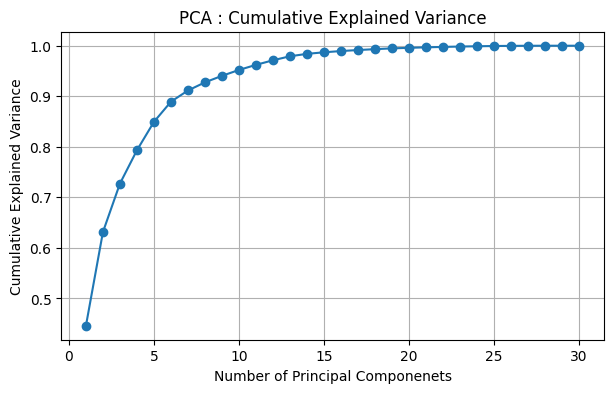

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cum_explained)+1), cum_explained, marker = "o")
plt.xlabel("Number of Principal Componenets")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA : Cumulative Explained Variance")
plt.grid(True)
plt.show()

**Choose Number of Componenets:(E.g. : Keep 95% Variance )**

In [30]:
n_components_95 = np.argmax(cum_explained >= 0.95) + 1
print("Componenets to reach 95% Variance:",n_components_95)

Componenets to reach 95% Variance: 10


**5. Fit PCA with Chosen number of Componenets**

In [31]:
pca = PCA(n_components=n_components_95)

In [32]:
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [33]:
X_train_pca.shape

(455, 10)

In [34]:
X_train_pca[:1]

array([[-0.87593746, -2.57130887, -0.54851057,  1.6357934 , -0.26283591,
         0.10981867,  0.50641431, -0.21445967, -0.10938357,  0.41669486]])

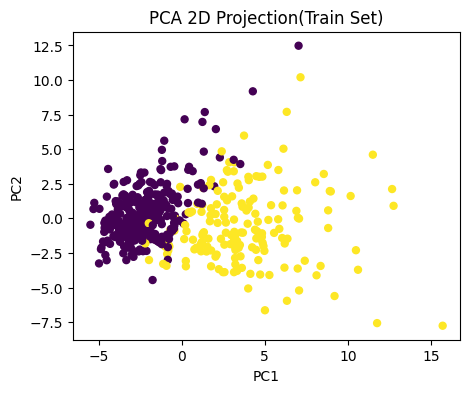

In [37]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)
plt.figure(figsize=(5,4))
plt.scatter(X_2d[:, 0],X_2d[:, 1],c = y_train, s= 25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection(Train Set)")
plt.show()

**6. Model Performance Comparision before v/s after PCA**

In [38]:
#Model Before PCA(on scaled original features)
model_before = LogisticRegression()
model_before.fit(X_train_scaled, y_train)
pred_before = model_before.predict(X_test_scaled)
acc_before = accuracy_score(y_test, pred_before)

#Model after PCA
model_after = LogisticRegression()
model_after.fit(X_train_pca, y_train)
pred_after = model_after.predict(X_test_pca)
acc_after = accuracy_score(y_test, pred_after)

# Model Accuracy comparision
print("=========Model Comaprision(Logistgic Regression========)")
print("Model Accuracy before implementing PCA:",acc_before)
print("Model Accuracy after implementing PCA:",acc_after)

print("classification Report before PCA:")
print(classification_report(y_test,pred_before))

print("Classification Report after PCA:")
print(classification_report(y_test,pred_after))

=========Model Comaprision(Logistgic Regression========)
Model Accuracy before implementing PCA: 0.9649122807017544
Model Accuracy after implementing PCA: 0.9736842105263158
classification Report before PCA:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Classification Report after PCA:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

